In [2]:
import os
import glob
import json
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from PNW_cmap import PNW_cmap
import matplotlib.pyplot as plt
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.glutamate.summary import GlutamateSummary
from matplotlib.patches import Rectangle
import matplotlib.image as mpimg

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [3]:
%matplotlib notebook

In [4]:
today_str = datetime.today().strftime('%Y-%m-%d')

In [5]:
save_path = r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Data_Club\April2026\figures"

In [28]:
target_mice = [
#     803496,
#     804730,804733,810196,
#     809047,
#     803121,
    826033,
#     838410,
#     834788
]

In [29]:
registry = VIPSessionRegistry.from_basepath(
    r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics'
)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=["expression_check","volume_imaging"],
    paradigms=["change_detection_passive"],
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

In [30]:
for i,asset in enumerate(assets):
    print(i, asset.session_dir, f'depths: DMD1 = {asset.metadata["dmd1_depth"]}, DMD2 = {asset.metadata["dmd2_depth"]}' )

0 \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-21_09-23-34 depths: DMD1 = 25, DMD2 = 200
1 \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-23_10-45-21 depths: DMD1 = 25, DMD2 = 200
2 \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-24_14-14-45 depths: DMD1 = 25, DMD2 = 200
3 \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-25_08-49-29 depths: DMD1 = 25, DMD2 = 200
4 \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-26_12-40-54 depths: DMD1 = 25, DMD2 = 200
5 \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-27_13-53-35 depths: DMD1 = 25, DMD2 = 200


In [31]:
cl, cmap, cp = PNW_cmap.get_PNW_cmap('Sailboat', n_colors=4)
cp

[(0.4823529411764706, 0.7372549019607844, 0.8352941176470589),
 (0.8156862745098039, 0.8862745098039215, 0.6862745098039216),
 (0.9607843137254901, 0.8588235294117647, 0.6),
 (0.9098039215686274, 0.611764705882353, 0.5058823529411764)]

In [32]:
cp  = cp[::-1]

### Find example synapses at each depth: 25, 100, 200, 250 um depths on novel days

In [45]:
shallow_session = assets[3]
shallow_session.session_id

'826033_2026-02-25_08-49-29'

In [46]:
shallow_glu_qc = glob.glob(os.path.join(shallow_session.qc_dir,'**','**glutamate_extraction**'),recursive=True)[0]

with open(shallow_glu_qc, "r") as f:
    s_glu_qc = json.load(f)

In [47]:
s_mean_data_path = glob.glob(os.path.join(shallow_session.derived_dir,'**','glutamate_mean_df.npz'))[0]
s_glu_mean = np.load(s_mean_data_path,allow_pickle=True)['data'][0]

In [48]:
im_names = list(s_glu_mean['DMD1']['image_identity'].keys())
colors = ['#c5cae9', '#ffcdd2', '#c8e6c9', '#ffe0b2',
 '#e1bee7', '#d7ccc8', '#cfd8dc', '#b2ebf2']

<IPython.core.display.Javascript object>


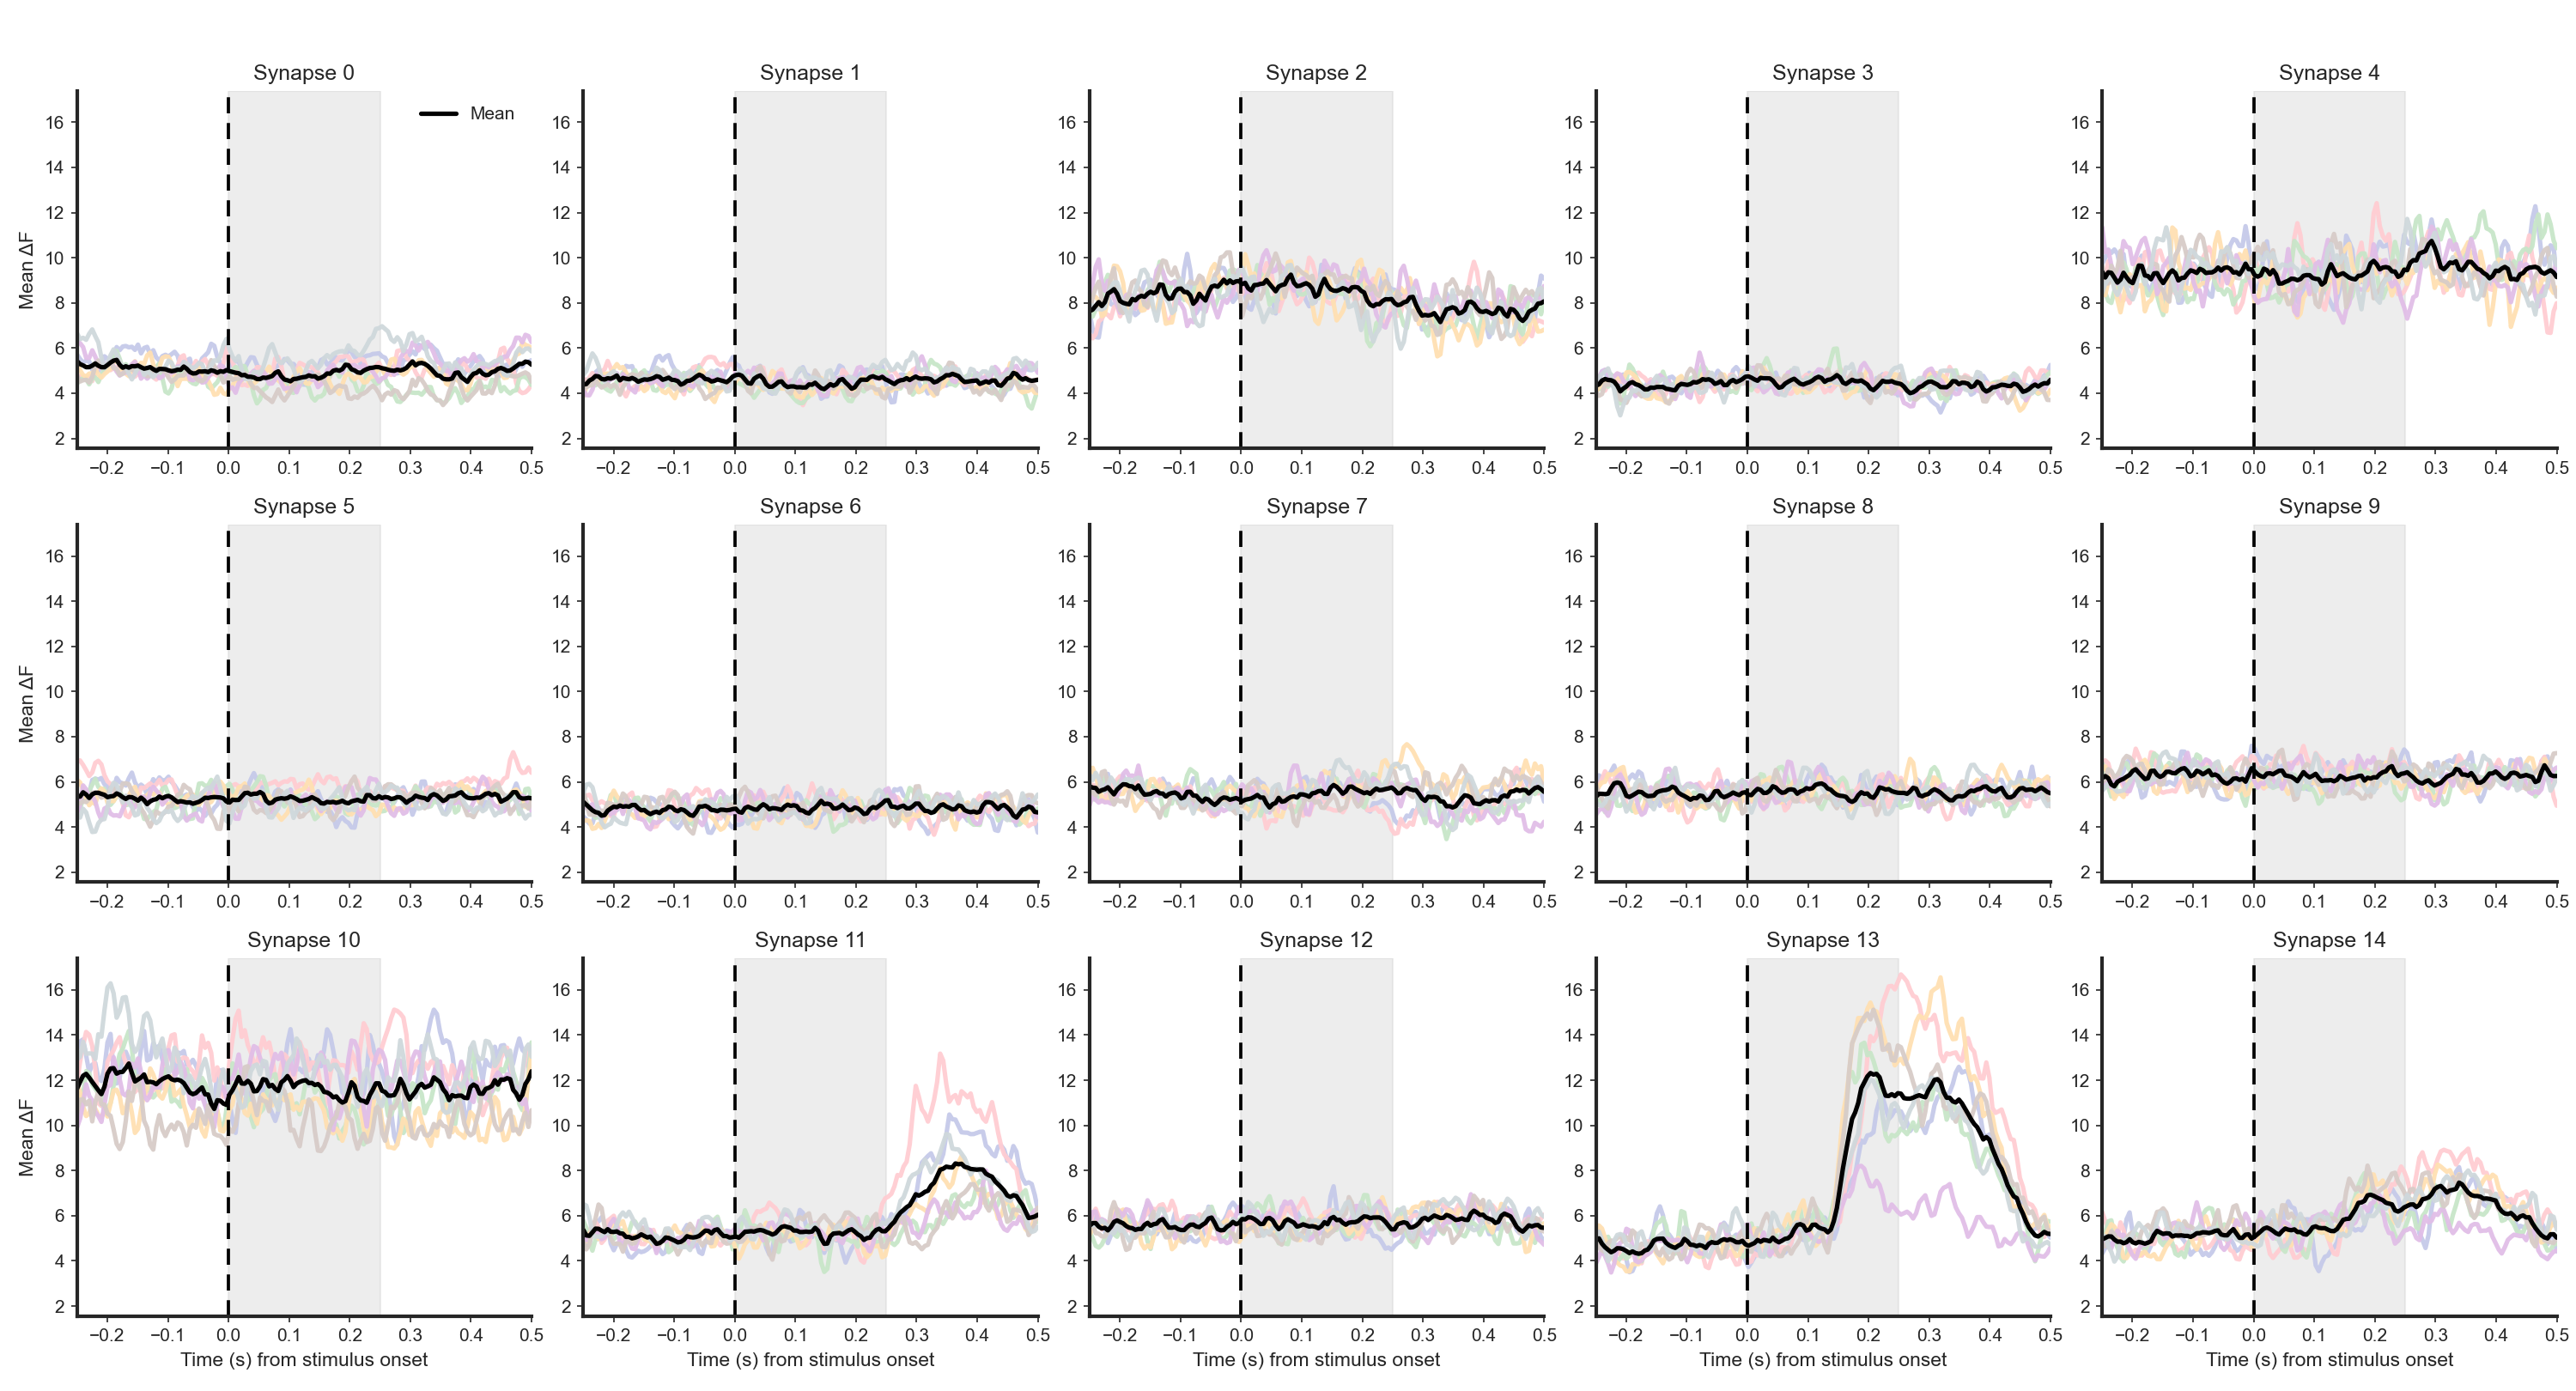

<IPython.core.display.Javascript object>


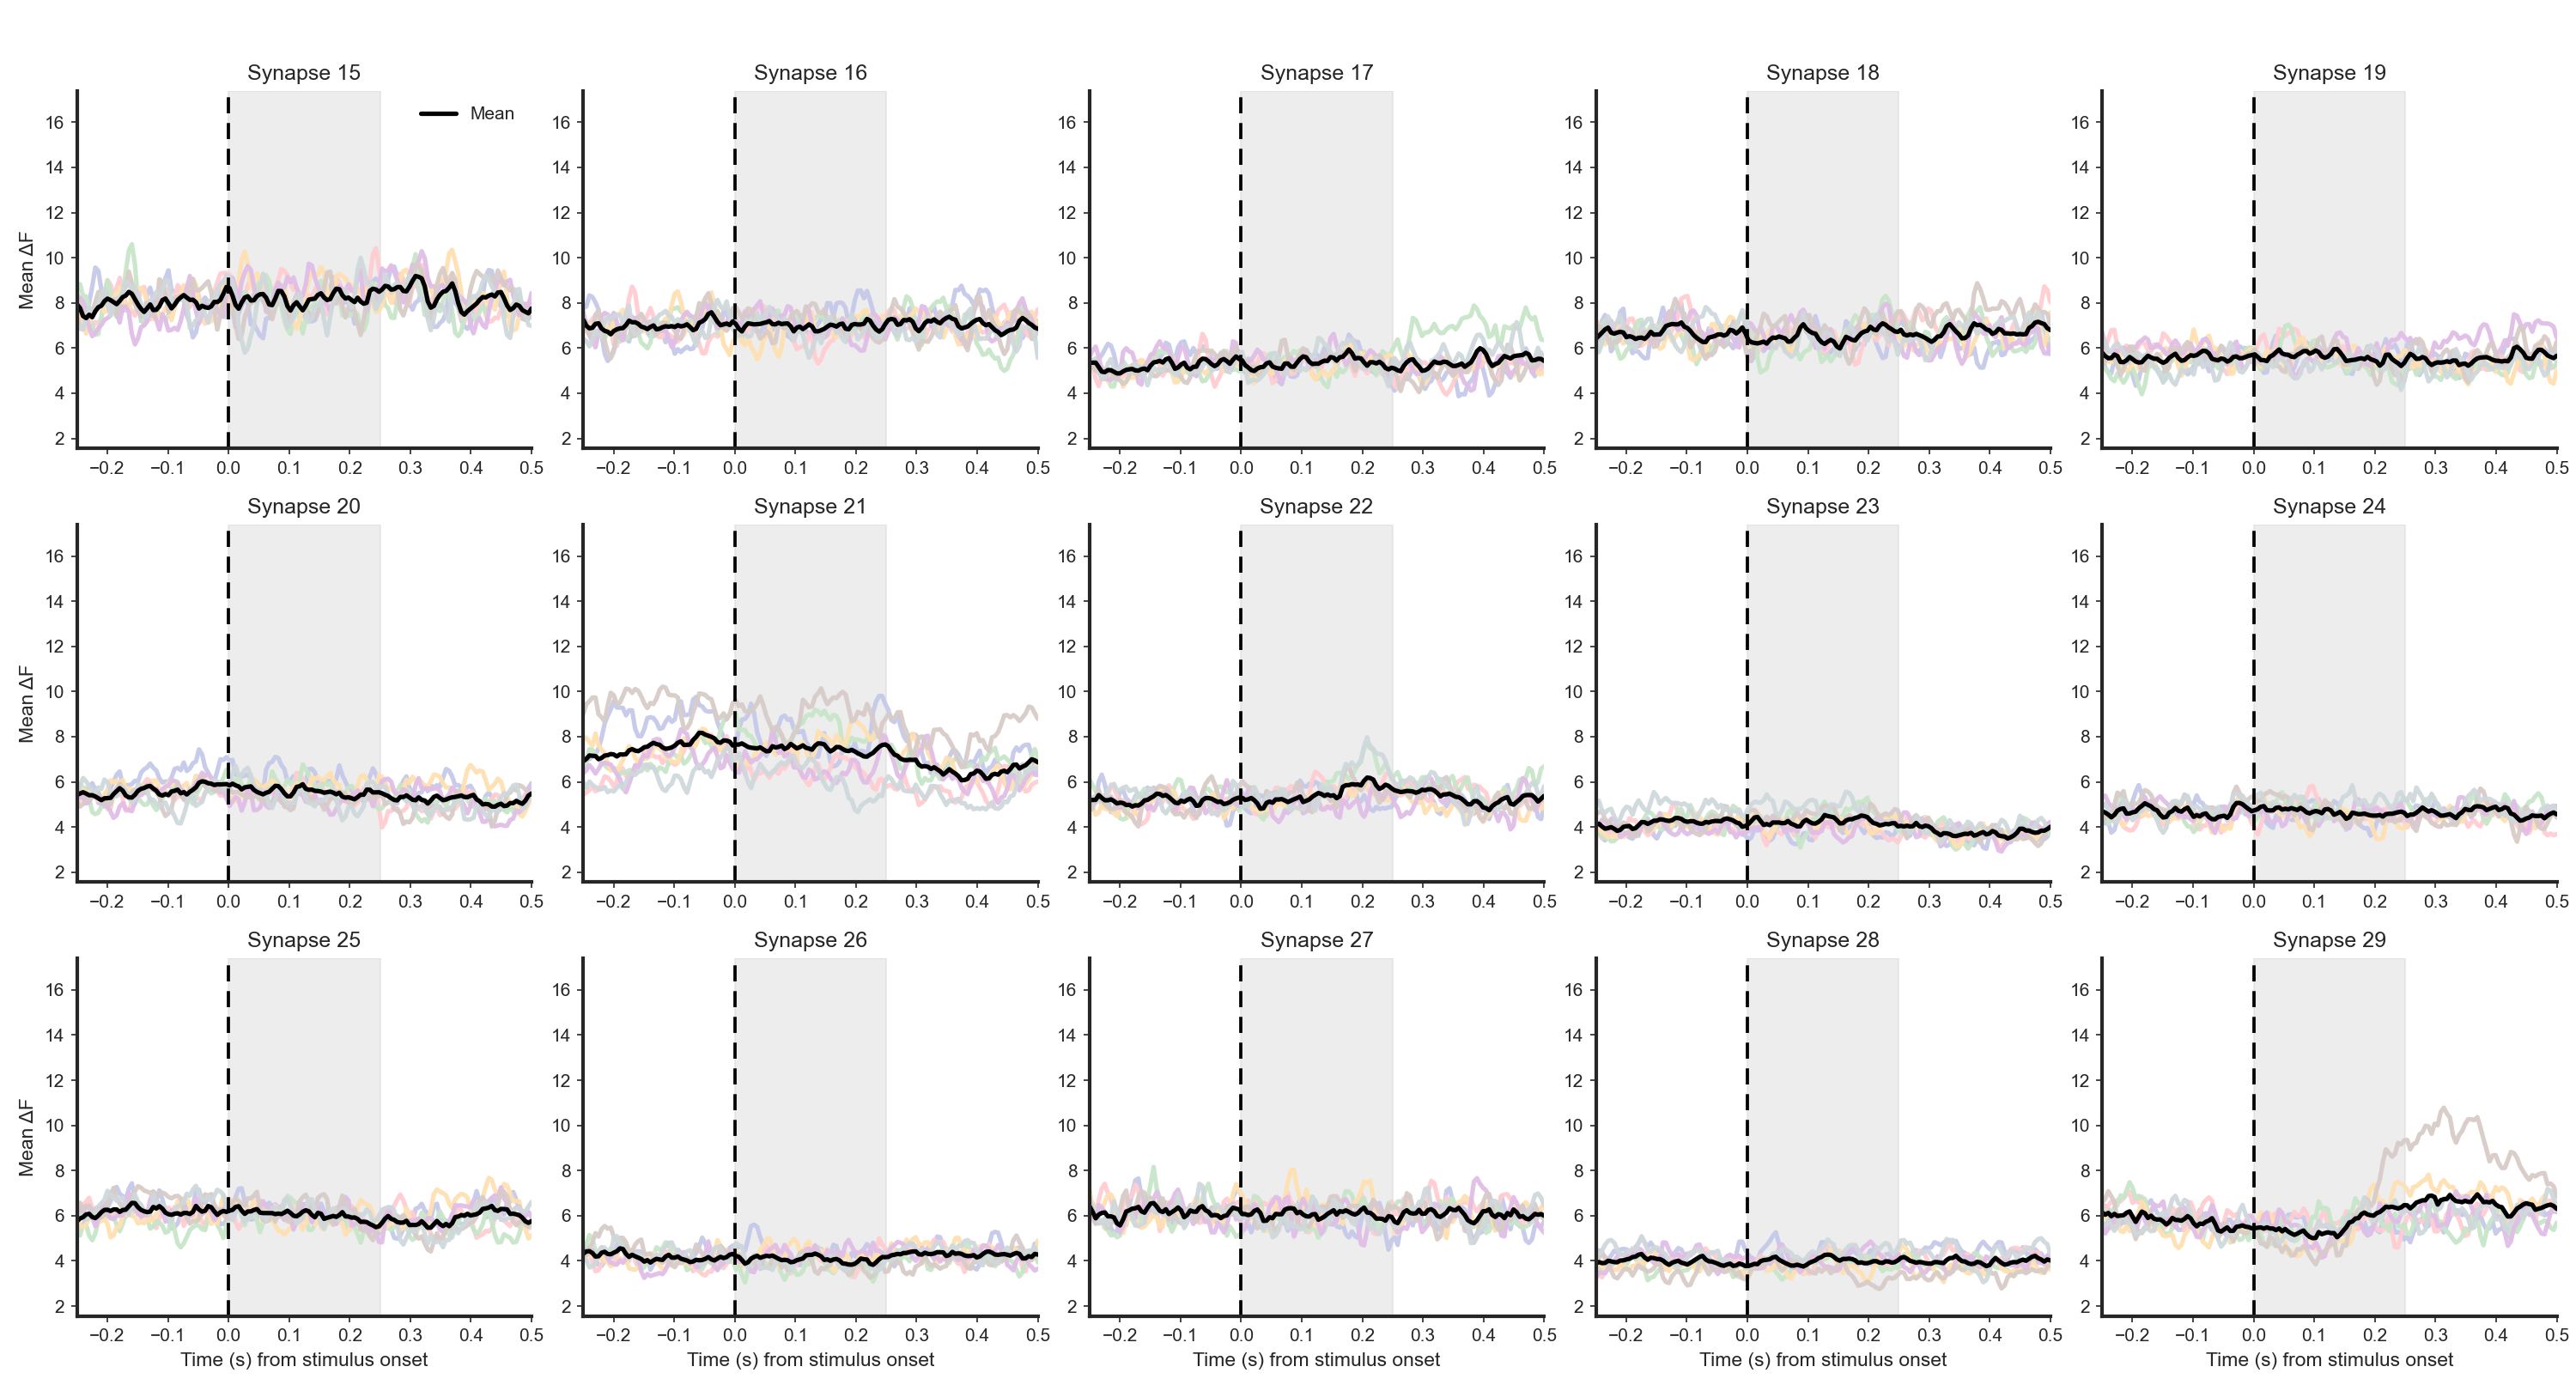

<IPython.core.display.Javascript object>


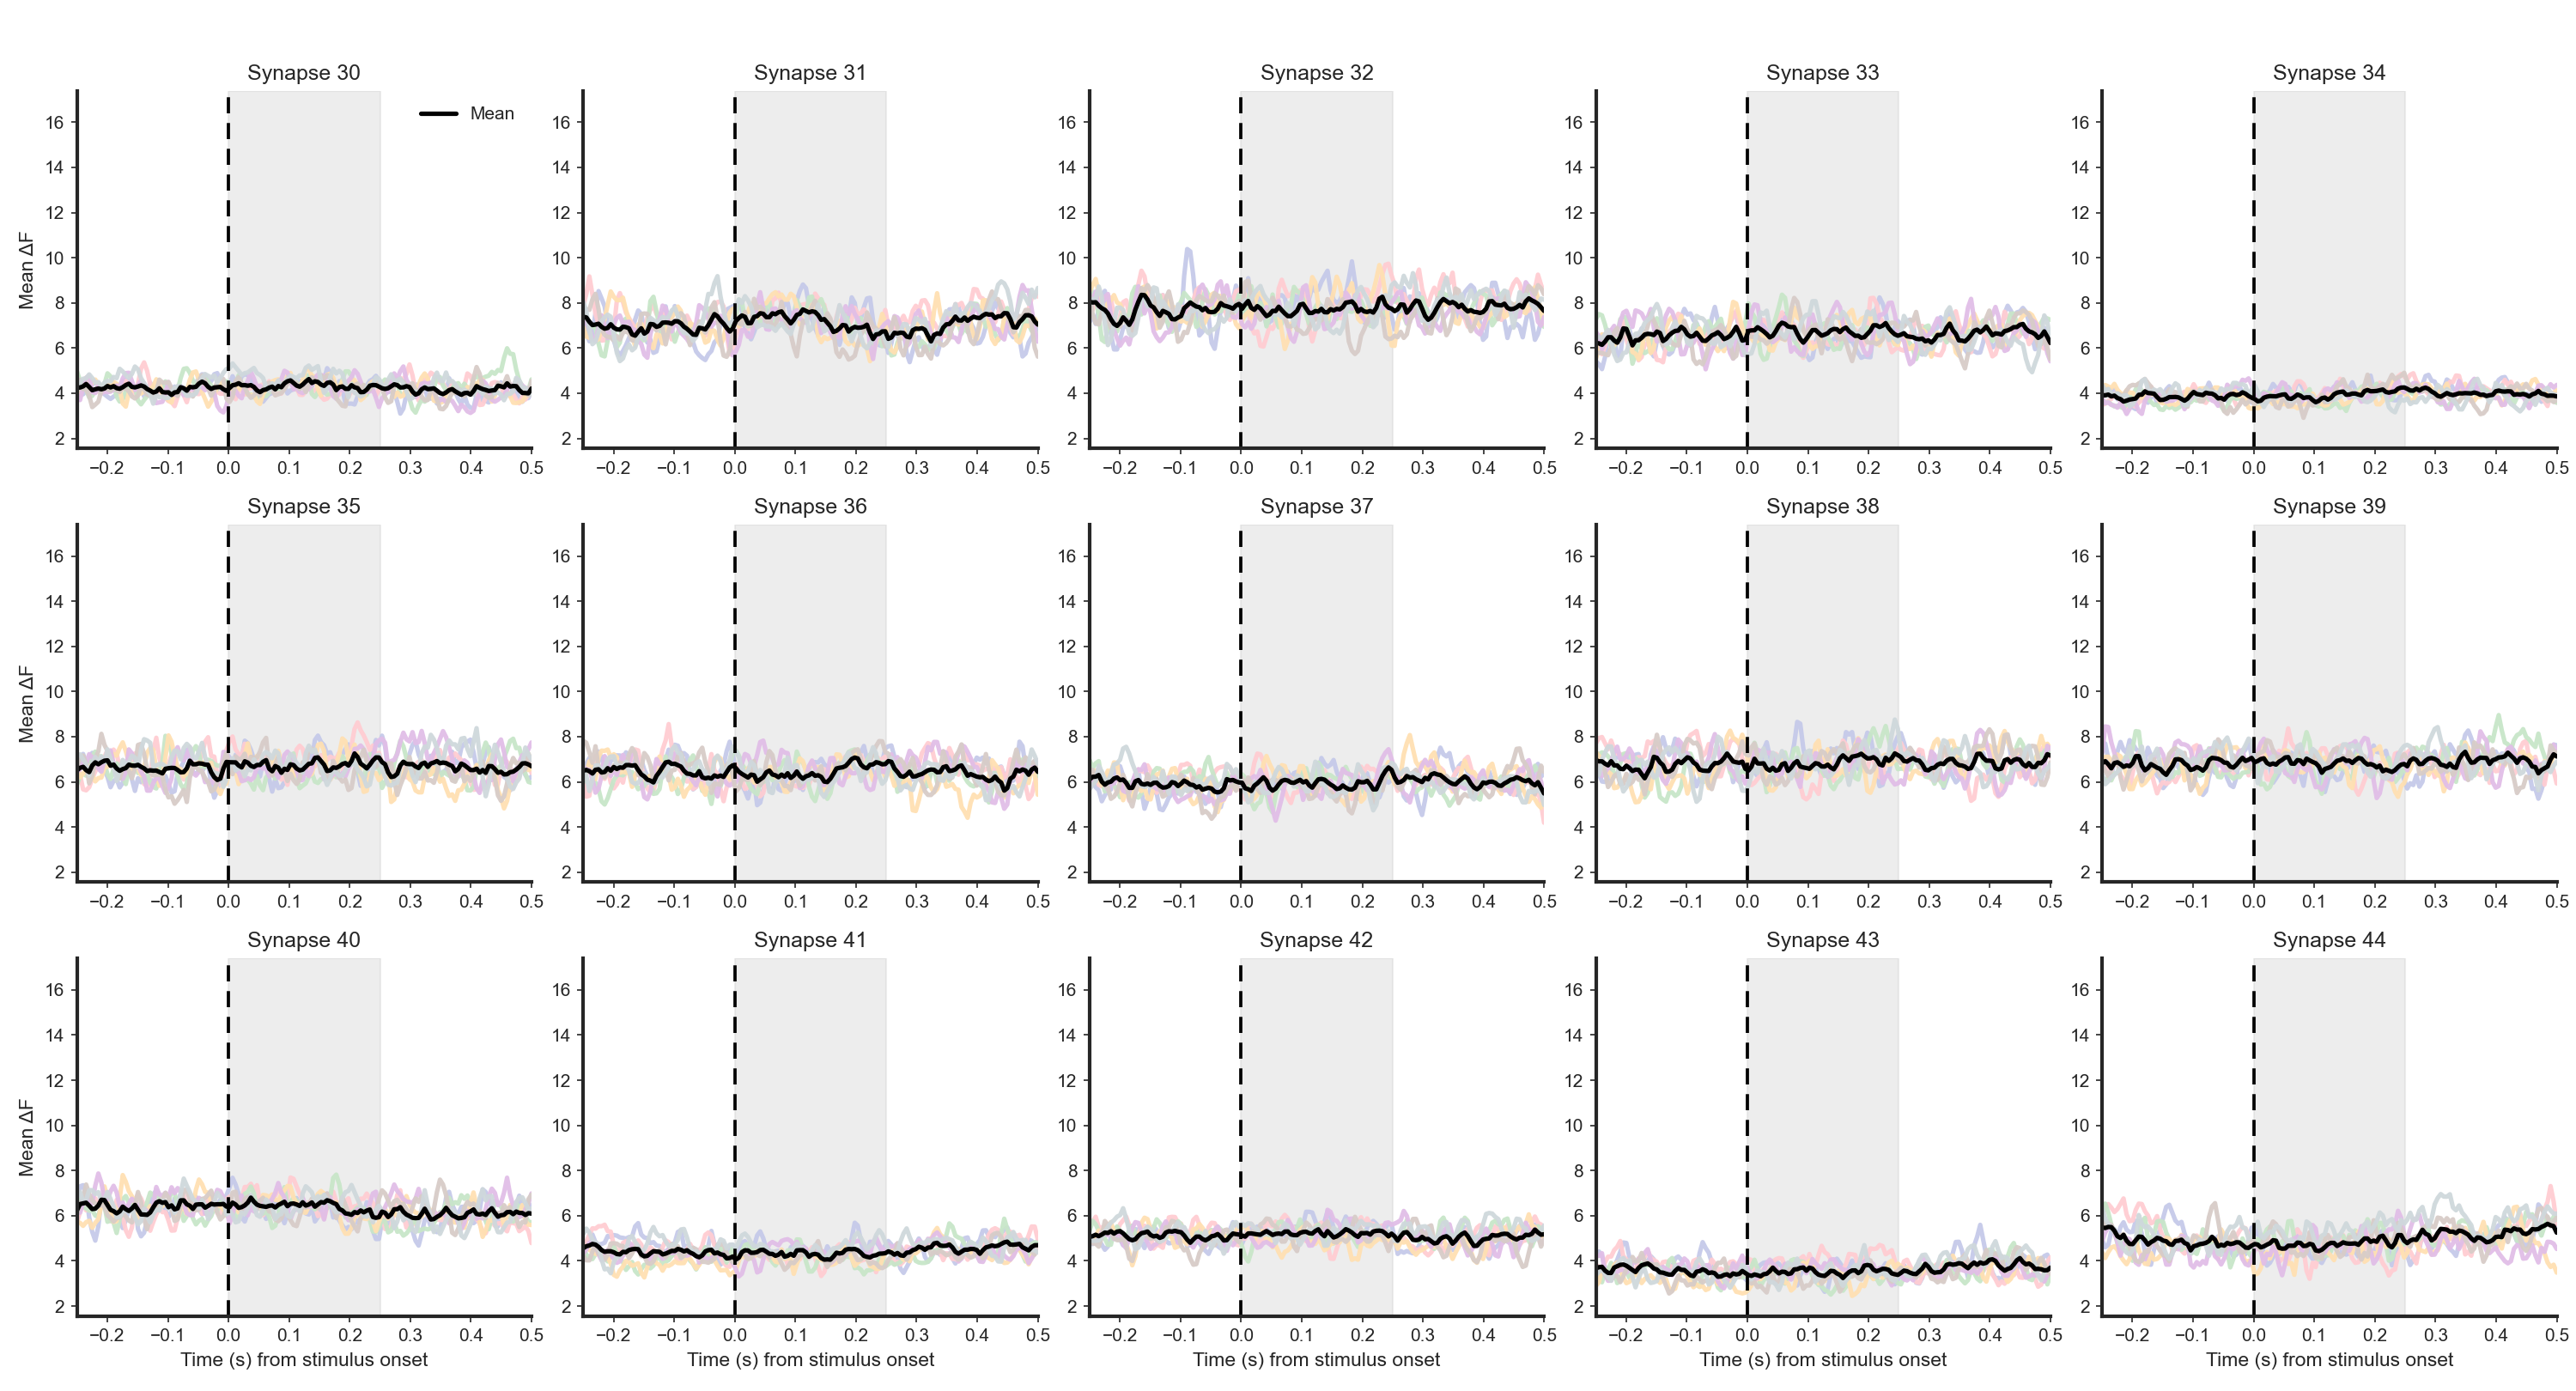

<IPython.core.display.Javascript object>


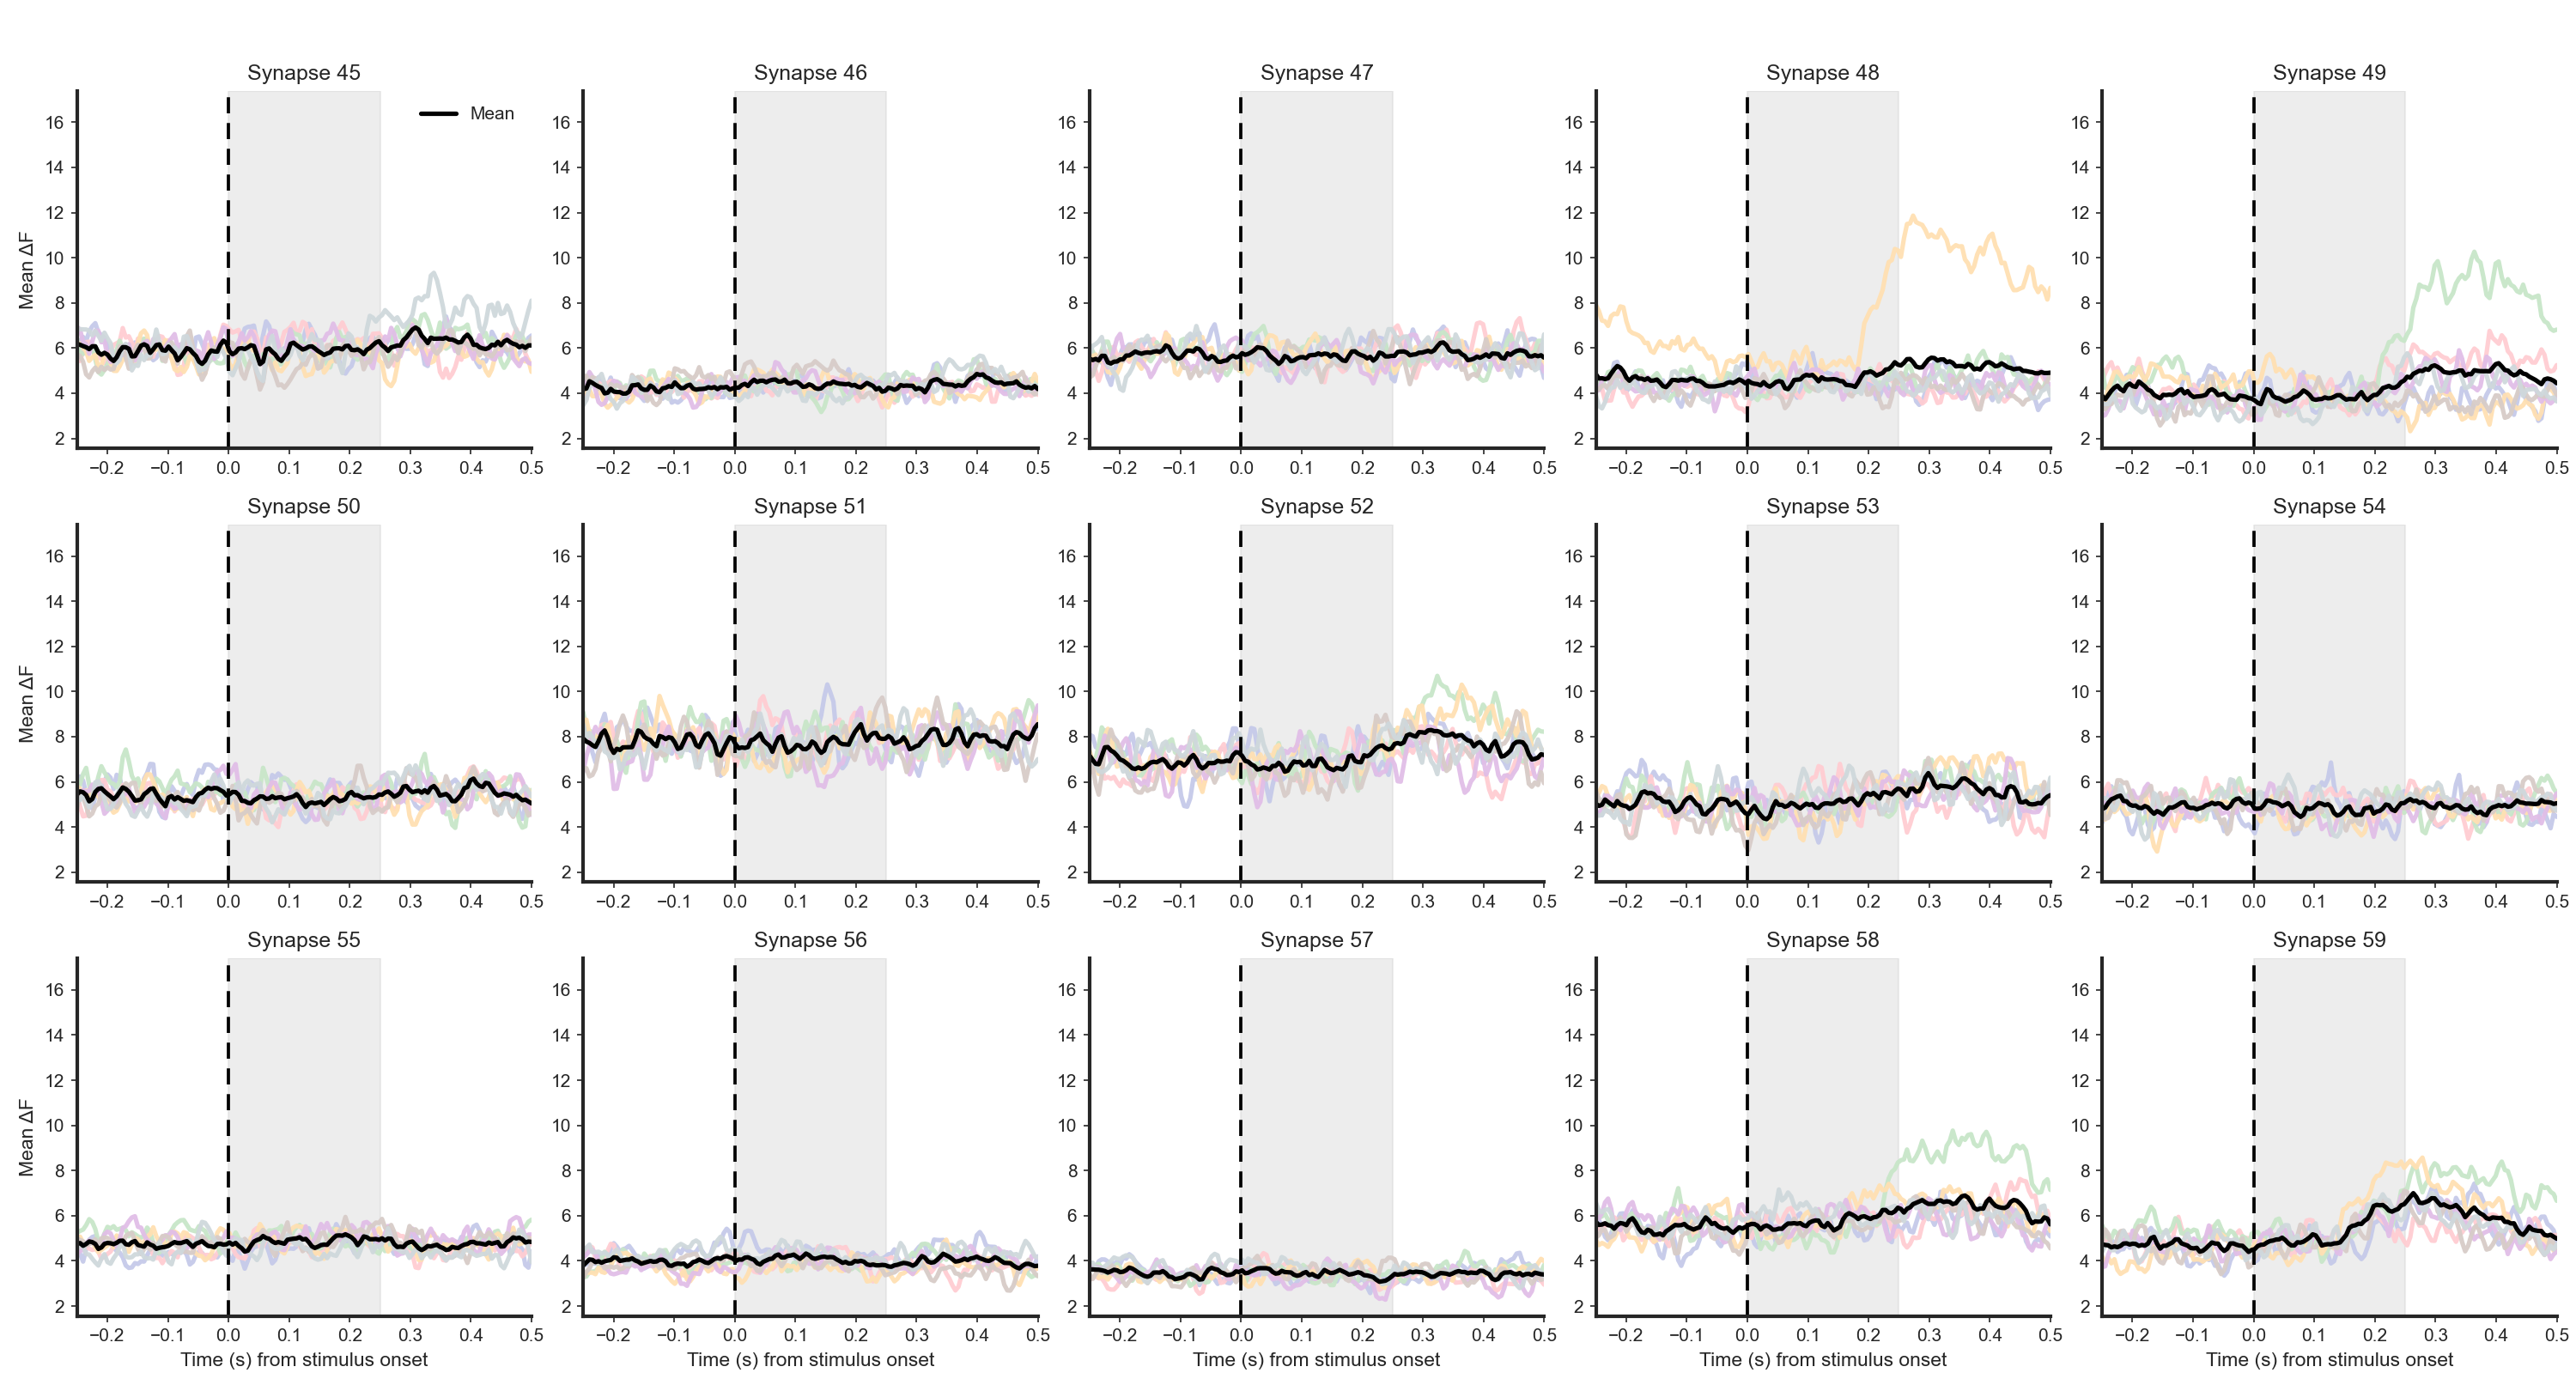

<IPython.core.display.Javascript object>


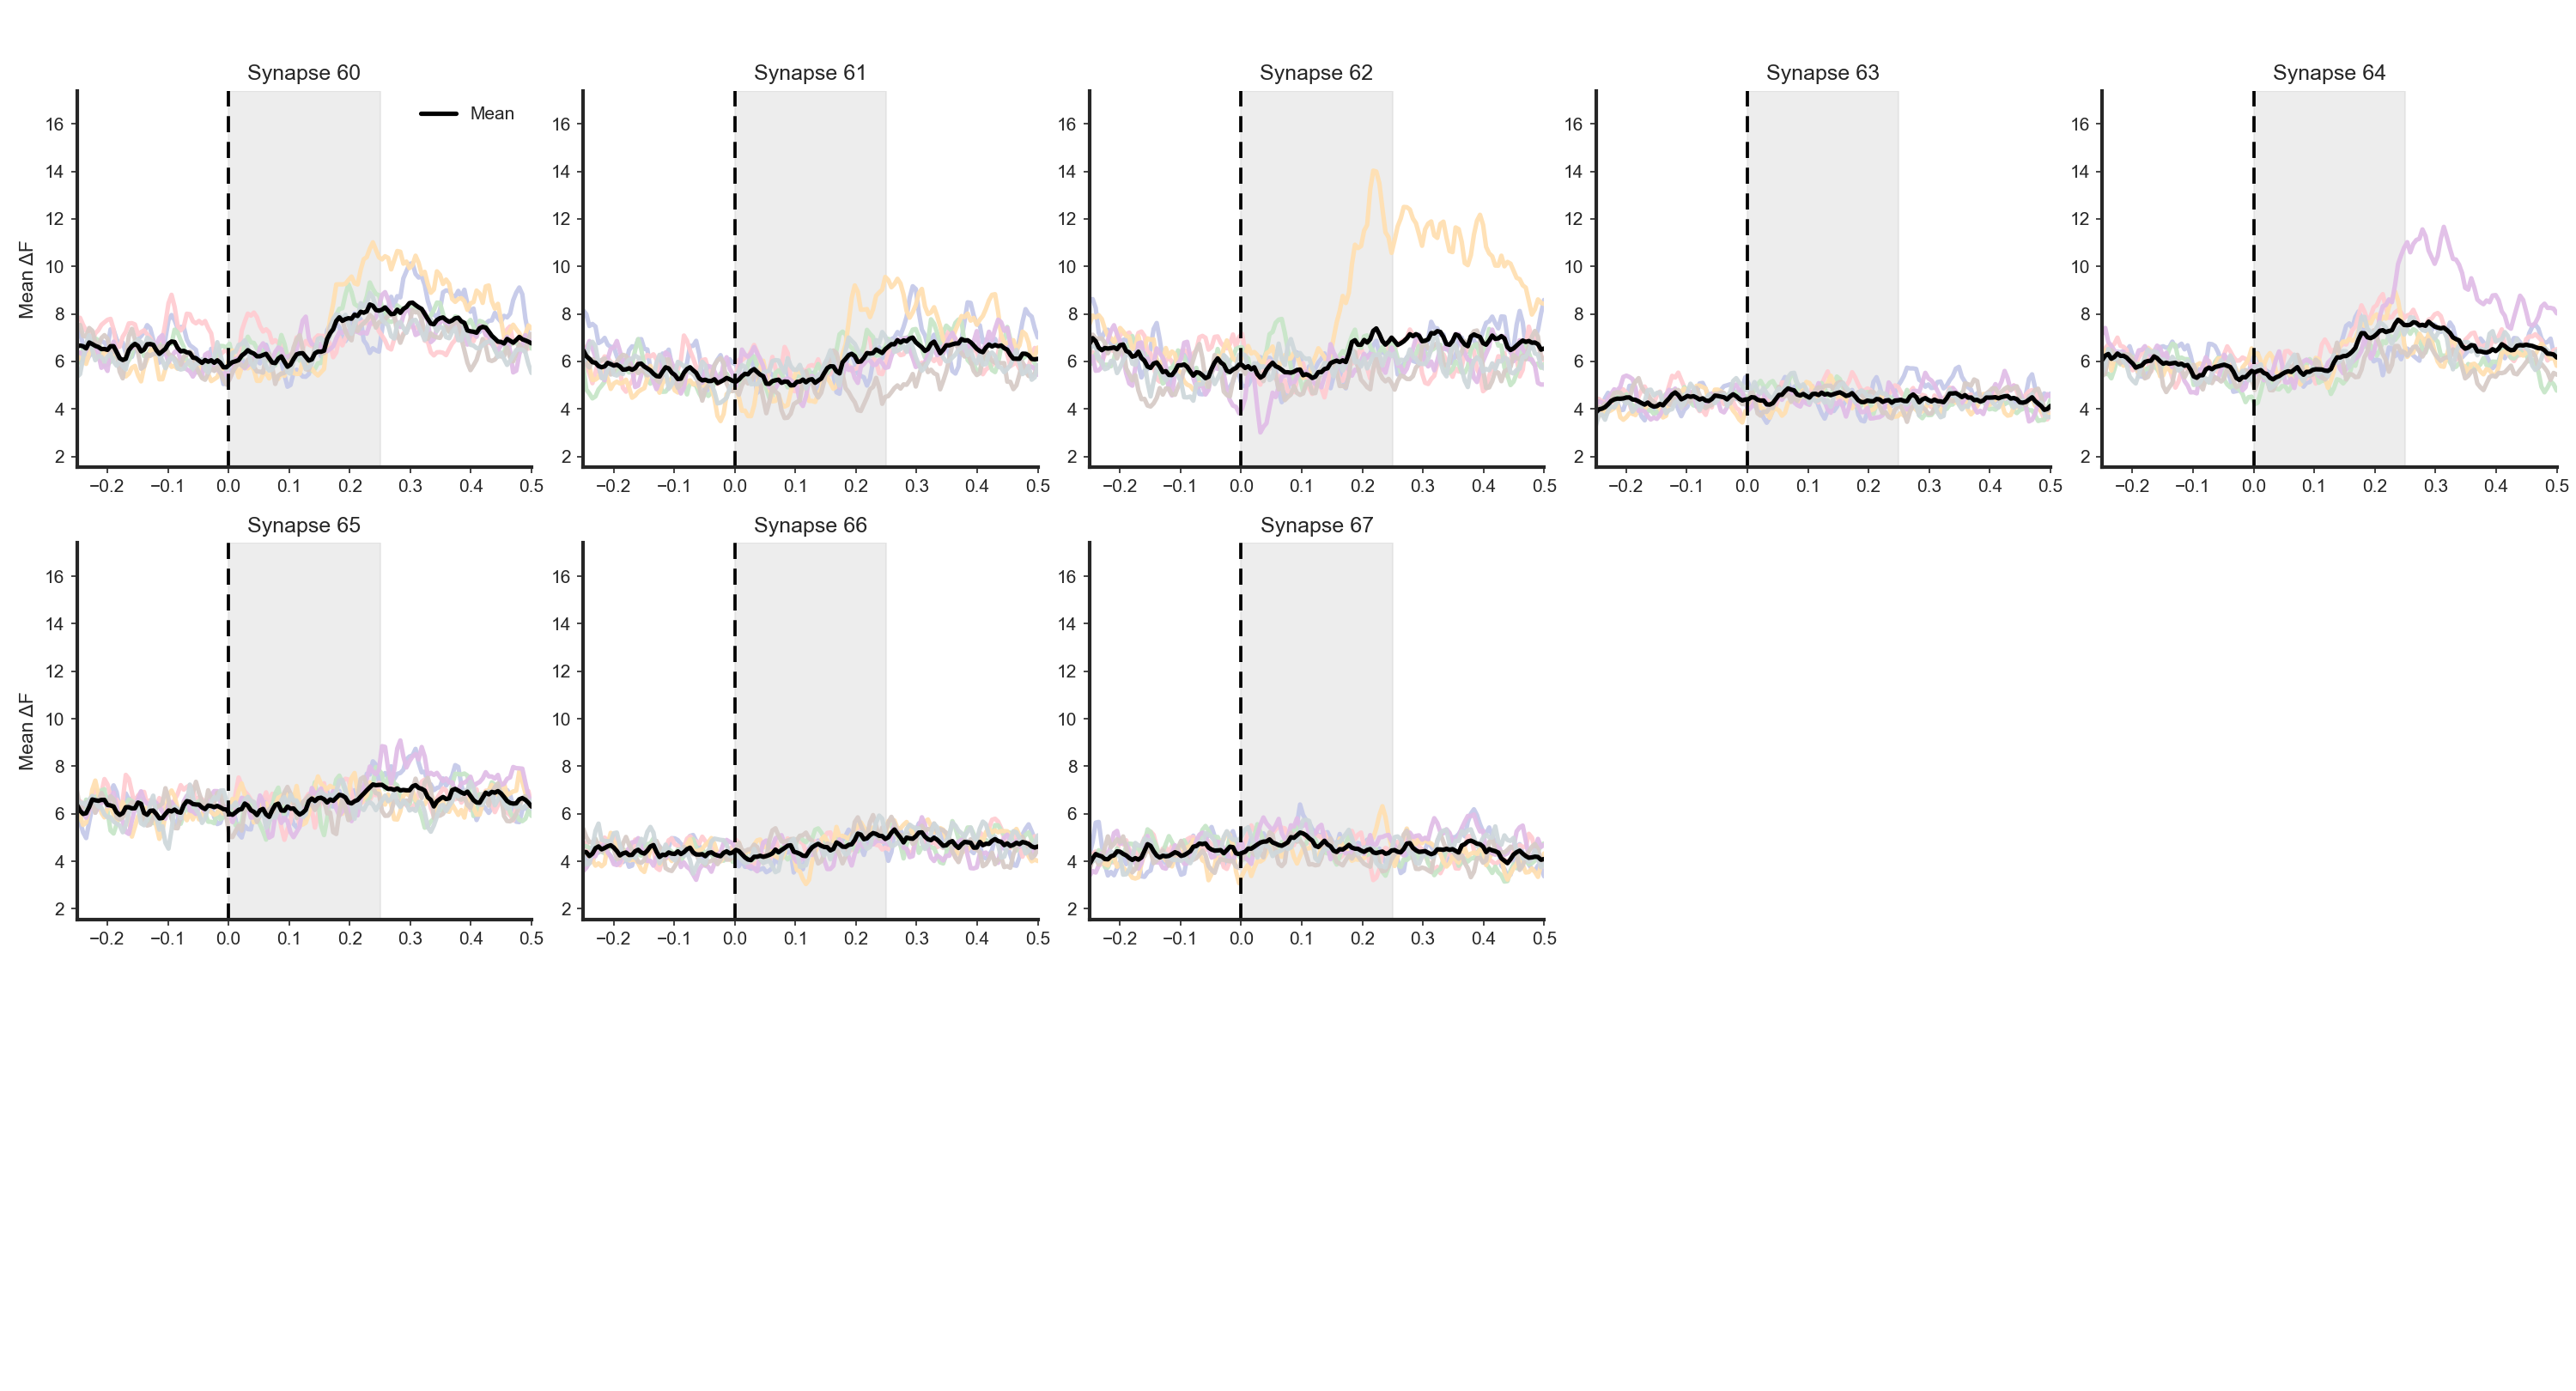

In [49]:
from matplotlib.backends.backend_pdf import PdfPages
import math

dmd = 1
ncols = 5
nrows = 3                       # 15 synapses per page
plots_per_page = ncols * nrows
rolling_win = 1
save_pdf = False                # set True to save multipage PDF
pdf_path = f"dmd{dmd}_mean_image_response_grid.pdf"

# infer number of synapses from the first image
n_synapses = s_glu_mean[f'DMD{dmd}']['image_identity'][im_names[0]]['mean'].shape[0]

# common time axis
example_signal = s_glu_mean[f'DMD{dmd}']['image_identity'][im_names[0]]['mean'][0]
time = np.linspace(-0.25, 0.5, len(example_signal))

# optional global y-limits across all synapses for this DMD
all_vals = []
for syn in range(n_synapses):
    for i, im in enumerate(im_names):
        glu_signal = s_glu_mean[f'DMD{dmd}']['image_identity'][im_names[i]]['mean'][syn]
        all_vals.append(np.asarray(glu_signal))
    mean_signal = np.mean(
        [s_glu_mean[f'DMD{dmd}']['image_identity'][im_names[i]]['mean'][syn] for i in range(len(im_names))],
        axis=0
    )
    all_vals.append(np.asarray(mean_signal))

all_vals = np.concatenate(all_vals)
ymin = np.nanmin(all_vals)
ymax = np.nanmax(all_vals)
ypad = 0.05 * (ymax - ymin) if ymax > ymin else 0.1
ymin -= ypad
ymax += ypad

n_pages = math.ceil(n_synapses / plots_per_page)
pdf = PdfPages(pdf_path) if save_pdf else None

for page in range(n_pages):
    start = page * plots_per_page
    stop = min(start + plots_per_page, n_synapses)
    syn_inds = np.arange(start, stop)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(4 * ncols, 3.6 * nrows),
        squeeze=False
    )
    axes = axes.flatten()

    for ax in axes:
        sns.despine(ax=ax)
        ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=10)
        ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=10)

    for ax_i, syn in enumerate(syn_inds):
        ax = axes[ax_i]

        for i, im in enumerate(im_names):
            glu_signal = s_glu_mean[f'DMD{dmd}']['image_identity'][im_names[i]]['mean'][syn]
            ax.plot(
                time,
                pd.DataFrame(glu_signal).rolling(rolling_win, min_periods=1).mean().values.squeeze(),
                lw=2.5,
                color=colors[i],
                alpha=0.95
            )

        mean_signal = np.mean(
            [s_glu_mean[f'DMD{dmd}']['image_identity'][im_names[i]]['mean'][syn] for i in range(len(im_names))],
            axis=0
        )

        ax.plot(
            time,
            pd.DataFrame(mean_signal).rolling(rolling_win, min_periods=1).mean().values.squeeze(),
            color='k',
            lw=2.5,
            label='Mean'
        )

        ax.axvline(0.0, color='k', dashes=[5, 3], lw=1.8)
        ax.axvspan(0.0, 0.25, color='lightgray', alpha=0.4, zorder=0)

        for spine in ['left', 'bottom']:
            ax.spines[spine].set_linewidth(2)

        ax.set_xlim(time.min(), time.max())
        ax.set_ylim(ymin, ymax)
        ax.set_title(f'Synapse {syn}', fontsize=12)

        # only label outer axes to keep it clean
        if ax_i % ncols == 0:
            ax.set_ylabel('Mean ΔF', fontsize=11)
        else:
            ax.set_ylabel('')

        if ax_i >= (nrows - 1) * ncols:
            ax.set_xlabel('Time (s) from stimulus onset', fontsize=11)
        else:
            ax.set_xlabel('')

        # only show legend once per page
        if ax_i == 0:
            ax.legend(frameon=False, fontsize=10, loc='upper right')

    # hide unused axes on last page
    for ax in axes[len(syn_inds):]:
        ax.axis('off')

    fig.suptitle(f'DMD {dmd+1} Mean Image Responses (page {page+1}/{n_pages})', fontsize=16, y=1.02)
    fig.tight_layout()

    if save_pdf:
        pdf.savefig(fig, bbox_inches='tight')

    plt.show()

if save_pdf:
    pdf.close()
    print(f"Saved multipage PDF to: {pdf_path}")

In [19]:
dmd = 2
syn = 97

fig,ax=plt.subplots(figsize=(4,4))

sns.despine()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

for i,im in enumerate(im_names):

    glu_signal = s_glu_mean[f'DMD{dmd}']['image_identity'][im_names[i]]['mean'][syn]
    time = np.linspace(-0.25,0.5,len(glu_signal))
    ax.plot(time,pd.DataFrame(glu_signal).rolling(1,min_periods=1).mean(),lw=3,color=colors[i])

mean = np.mean([s_glu_mean[f'DMD{dmd}']['image_identity'][im_names[i]]['mean'][syn]for i,im in enumerate(im_names)],axis=0 )

# ax.fill_between(time[50:100],min(mean[50:100]),mean[50:100],color='lightgray',zorder=0,alpha=0.4,label='AUC')
# ax.fill_between(time[:50],min(mean[:50]),mean[:50],color='lightgray',zorder=0,alpha=0.4)

ax.plot(time,pd.DataFrame(mean).rolling(1,min_periods=1).mean(),color='k',lw=2,label='Mean')

ax.axvline(0.0,color='k',dashes=[5,3],lw=2)
ax.axvspan(0.0,0.25,color='lightgray',alpha=0.4,zorder=0)

ax.set_xlabel('Time (s) from stimulus onset')
ax.set_ylabel('Mean \u0394F')

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)

ax.set_title('Mean Image Response')
ax.legend(frameon=False,fontsize=12)
fig.tight_layout()
filen = 'exampled_tuned'
save_figure(fig,os.path.join(save_path,filen),formats=['.pdf','.png'],dpi=300)

<IPython.core.display.Javascript object>

In [24]:
dmd = 2
syn = 97

fig,ax=plt.subplots(figsize=(5,4))

sns.despine()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

resps = []

for i,im in enumerate(im_names):

    glu_signal = s_glu_mean[f'DMD{dmd}']['image_identity'][im_names[i]]['mean'][syn]
    
    resps.append(glu_signal[50:150])
omission_signal = s_glu_mean[f'DMD{dmd}']['omission']['mean'][syn]
resps.append(np.ravel(pd.DataFrame(omission_signal[350:450]).rolling(10,min_periods=1).mean().values))


trace = np.concatenate(resps)
time = np.linspace(0,len(trace)/200,len(trace))
ax.plot(time,trace,color='k',lw=1.5)

starts = [0.0+0.5*i for i in range(8)]

for i,start in enumerate(starts):
    ax.axvspan(start,start+0.25,alpha=0.5,zorder=0,color=colors[i])

# ax.set_ylim(0,30)
for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)
    
ax.set_xlabel('Time (s)')
ax.set_ylabel('Mean \u0394F')
    
fig.tight_layout()
filen = 'exampled_trtc'
save_figure(fig,os.path.join(save_path,filen),formats=['.pdf','.png'],dpi=300)

<IPython.core.display.Javascript object>

In [ ]:
starts

In [ ]:
np.ravel(pd.DataFrame(omission_signal[300:450]).rolling(20,min_periods=1).mean().values)

### Time-resolved tuning curve for example synapses (assets[33])

In [ ]:
# --------------------------------------------------
# settings
# --------------------------------------------------
cl, cmap, cp = PNW_cmap.get_PNW_cmap('Sailboat', n_colors=4)
cp = cp[::-1]

im_colors = [
    '#c5cae9', '#ffcdd2', '#c8e6c9', '#ffe0b2',
    '#e1bee7', '#d7ccc8',
    '#9fd3f2',   # final image: distinct light blue
    '#d9d9d9'    # omission: light gray
]

asset_25_100 = assets[21]   # DMD1 = 25,  DMD2 = 100
asset_200_250 = assets[33]  # DMD1 = 200, DMD2 = 250

example_indices = {
    25:  [36, 4, 27],
    100: [4, 30, 28],
    200: [23, 34, 56],
    250: [10, 57, 86],
}

stim_image_dir = Path(
    r"C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\Aind.Behavior.ChangeDetection\src\stimuli\images_B"
)

rolling_win = 5
figsize = (10, 12)
trace_lw_color = 4
trace_lw_black = 2.5
thumb_alpha = 1.0
shade_alpha = 0.4

# --------------------------------------------------
# load npz files
# --------------------------------------------------
npz_25_100 = glob.glob(
    os.path.join(asset_25_100.derived_dir, '**', 'glutamate_mean_df.npz'),
    recursive=True
)[0]

npz_200_250 = glob.glob(
    os.path.join(asset_200_250.derived_dir, '**', 'glutamate_mean_df.npz'),
    recursive=True
)[0]

glu_25_100 = np.load(npz_25_100, allow_pickle=True)['data'].item()
glu_200_250 = np.load(npz_200_250, allow_pickle=True)['data'].item()

depth_blocks = {
    25:  glu_25_100['DMD1'],
    100: glu_25_100['DMD2'],
    200: glu_200_250['DMD1'],
    250: glu_200_250['DMD2'],
}
depths = [25, 100, 200, 250]

# --------------------------------------------------
# top-row images only
# --------------------------------------------------
template_block = depth_blocks[25]
template_im_keys = list(template_block['image_identity'].keys())[:7]
template_im_stems = [Path(k).stem for k in template_im_keys]

thumbs = []
for stem in template_im_stems:
    tif_path = stim_image_dir / f"{stem}.tiff"
    if tif_path.exists():
        thumbs.append(mpimg.imread(tif_path))
    else:
        thumbs.append(None)

# --------------------------------------------------
# time: only samples [50:150] -> [0.0, 0.5]
# --------------------------------------------------
sl = slice(40, 150)
t = np.linspace(0.0, 0.5, 110)

# --------------------------------------------------
# figure layout
# --------------------------------------------------
n_rows_per_depth = 3
n_trace_rows = len(depths) * n_rows_per_depth

fig = plt.figure(figsize=figsize)
gs = fig.add_gridspec(
    nrows=n_trace_rows + 1,
    ncols=8,
    height_ratios=[1.0] + [1] * n_trace_rows,
    hspace=0.10,
    wspace=0.0   # no horizontal space between panels
)

# --------------------------------------------------
# top image row
# --------------------------------------------------
top_pad = 0.035
border_lw = 2

for col in range(8):
    ax = fig.add_subplot(gs[0, col])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('white')

    # titles
    if col < 7:
        ax.set_title(template_im_stems[col], fontsize=11, pad=8)
    else:
        ax.set_title('Image\nOmission', fontsize=11, pad=8)

    # hide default spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    # draw inset colored border box
    rect = Rectangle(
        (top_pad, top_pad),
        1 - 2 * top_pad,
        1 - 2 * top_pad,
        transform=ax.transAxes,
        fill=False,
        linewidth=border_lw,
        edgecolor=im_colors[col],
        zorder=4,
        joinstyle='miter'
    )
    ax.add_patch(rect)

    if col < 7 and thumbs[col] is not None:
        ax.imshow(
            thumbs[col],
            cmap='Greys_r',
            aspect='auto',
            alpha=thumb_alpha,
            extent=(top_pad, 1 - top_pad, top_pad, 1 - top_pad),
            transform=ax.transAxes,
            zorder=2
        )
    else:
        ax.set_facecolor('white')

# --------------------------------------------------
# plot rows
# --------------------------------------------------
row_counter = 1

for depth_i, depth in enumerate(depths):
    block = depth_blocks[depth]
    syns = example_indices[depth]
    depth_color = cp[depth_i]

    block_im_keys = list(block['image_identity'].keys())[:7]

    per_image_means_full = [
        np.asarray(block['image_identity'][k]['mean'])
        for k in block_im_keys
    ]
    per_image_means = [arr[:, sl] for arr in per_image_means_full]

    overall_mean = np.nanmean(np.stack(per_image_means, axis=0), axis=0)

    omission_mean_full = np.asarray(block['omission']['mean'])
    omission_mean = omission_mean_full[:, sl]

    syns = [s for s in syns if s < overall_mean.shape[0]]

    if len(syns) == 0:
        print(f'No valid synapse indices for depth {depth}')
        row_counter += n_rows_per_depth
        continue

    for syn_i in range(n_rows_per_depth):
        syn = syns[syn_i] if syn_i < len(syns) else None

        if syn is not None:
            row_image_traces = np.stack([per_image_means[col][syn] for col in range(7)], axis=0)
            row_grand_mean = overall_mean[syn]

            yvals = np.concatenate([row_image_traces.ravel(), row_grand_mean.ravel()])
            ymin = np.nanmin(yvals)
            ymax = np.nanmax(yvals)

            if np.isfinite(ymin) and np.isfinite(ymax):
                if ymax > ymin:
                    ypad = 0.10 * (ymax - ymin)
                else:
                    ypad = max(abs(ymax) * 0.1, 0.01)
            else:
                ymin, ymax, ypad = -0.1, 0.1, 0.02

            ymin -= ypad
            ymax += ypad
        else:
            ymin, ymax = -0.1, 0.1

        for col in range(8):
            ax = fig.add_subplot(gs[row_counter, col])

            sns.despine(ax=ax, bottom=True)
            ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12, length=7, width=2, pad=2)
            ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=10, length=0)

            ax.axvspan(0.0, 0.25, color=im_colors[col], alpha=shade_alpha, zorder=0)
            ax.axvline(0.0, color='k', dashes=[5, 3], lw=2, alpha=0.85, zorder=1)

            if syn is not None:
                mean_trace = (
                    pd.DataFrame(overall_mean[syn])
                    .rolling(rolling_win, min_periods=1)
                    .mean()
                    .values
                    .squeeze()
                )

                ax.plot(
                    t, mean_trace,
                    color='k',
                    lw=trace_lw_black,
                    alpha=1,
                    zorder=3
                )

                if col < 7:
                    img_trace = (
                        pd.DataFrame(per_image_means[col][syn])
                        .rolling(rolling_win, min_periods=1)
                        .mean()
                        .values
                        .squeeze()
                    )
                    ax.plot(
                        t, img_trace,
                        color=depth_color,
                        lw=trace_lw_color,
                        alpha=1,
                        zorder=2
                    )
                else:
                    om_trace = (
                        pd.DataFrame(omission_mean[syn])
                        .rolling(rolling_win, min_periods=1)
                        .mean()
                        .values
                        .squeeze()
                    )
                    ax.plot(
                        t, om_trace,
                        color=depth_color,
                        lw=trace_lw_color,
                        alpha=1,
                        zorder=2
                    )

            ax.set_xlim(0.0, 0.5)
            ax.set_ylim(ymin, ymax)
            ax.set_yticks([])

            if col == 0:
                ax.set_ylabel(f'{depth}', fontsize=20, rotation=90)
            else:
                ax.set_ylabel('')

            # spine styling
            ax.spines['bottom'].set_visible(False)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(2)

            # unique x ticks only on the bottom row
            if row_counter < n_trace_rows:
                ax.set_xticks([])
                ax.set_xticklabels([])
            else:
                if col == 0:
                    ax.set_xticks([0.0, 0.5])
                    ax.set_xticklabels(['0.0', '0.5'])
                else:
                    ax.set_xticks([0.5])
                    ax.set_xticklabels([f'{(col + 1) * 0.5:.1f}'])

                if col == 3:
                    ax.set_xlabel('Time (s)', fontsize=34)
                else:
                    ax.set_xlabel('')

        row_counter += 1

fig.text(
    0.03, 0.12,
    'Depth (μm)',
    rotation=90,
    va='center',
    ha='center',
    fontsize=34
)

fig.tight_layout(rect=(0.06, 0.03, 1, 1))

filen = f'{today_str}_trtc_example'
# save_figure(fig,os.path.join(save_path,filen),formats=['.pdf'],dpi=300)